# RT-DETR End-to-End Pipeline 

This notebook demonstrates a complete pipeline for RT-DETR (Real-Time Detection Transformer), including:

- Dataset preparation (COCO128)
- Model training using PyTorch
- Model evaluation (COCO metrics)
- ONNX export
- TensorRT optimization

The objective is to build a scalable pipeline from training to deployment.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/ultralytics/coco128/coco128/LICENSE
/kaggle/input/datasets/organizations/ultralytics/coco128/coco128/README.txt
/kaggle/input/datasets/organizations/ultralytics/coco128/coco128/labels/train2017/000000000110.txt
/kaggle/input/datasets/organizations/ultralytics/coco128/coco128/labels/train2017/000000000431.txt
/kaggle/input/datasets/organizations/ultralytics/coco128/coco128/labels/train2017/000000000368.txt
/kaggle/input/datasets/organizations/ultralytics/coco128/coco128/labels/train2017/000000000564.txt
/kaggle/input/datasets/organizations/ultralytics/coco128/coco128/labels/train2017/000000000073.txt
/kaggle/input/datasets/organizations/ultralytics/coco128/coco128/labels/train2017/000000000144.txt
/kaggle/input/datasets/organizations/ultralytics/coco128/coco128/labels/train2017/000000000321.txt
/kaggle/input/datasets/organizations/ultralytics/coco128/coco128/labels/train2017/000000000581.txt
/kaggle/input/datasets/organizations/ultralytics/coco128/co

## Milestone 1: DataSet Preparation (20 Points)
###  Implementation Steps

The following steps were performed to prepare the dataset:

1. Cloned RT-DETR repository and installed dependencies  
2. Downloaded COCO128 dataset for lightweight experimentation  
3. Loaded pretrained weights for initialization  
4. Structured dataset into RT-DETR compatible format  
5. Split dataset into training (100) and validation (28)  
6. Converted YOLO annotations → COCO JSON format  

In [ ]:
# Clone the RT-DETR repository and set up the environment
!git clone https://github.com/lyuwenyu/RT-DETR.git
%cd RT-DETR/rtdetr_pytorch
!pip install pycocotools -q
!pip install addict -q

import torch
print(f"PyTorch: {torch.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Cloning into 'RT-DETR'...
remote: Enumerating objects: 1124, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 1124 (delta 17), reused 7 (delta 7), pack-reused 1083 (from 2)
Receiving objects: 100% (1124/1124), 670.17 KiB | 6.70 MiB/s, done.
Resolving deltas: 100% (533/533), done.
/kaggle/working/RT-DETR/rtdetr_pytorch/RT-DETR/rtdetr_pytorch
PyTorch: 2.10.0+cu128
GPU: Tesla T4


### Download Dataset
Downloading COCO128 dataset for experimentation.

In [ ]:
# Download the COCO128 dataset for testing
import os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')
# download data
!wget -q https://ultralytics.com/assets/coco128.zip
!unzip -q -o coco128.zip
print("Dataset downloaded") 

Dataset downloaded


### Load Pretrained Weights
Loading RT-DETR pretrained weights for initialization.

In [6]:
import os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')

if not os.path.exists('rtdetr_r18vd_6x_coco.pth'):
    print("Downloading weights...")
    !wget -q --show-progress \
        https://huggingface.co/PekingU/rtdetr_r18vd_coco_o365/resolve/main/model.safetensors \
        -O rtdetr_r18vd_6x_coco.pth

print("Weights ready")

rtdetr_r18vd_6x_coc 100%[===================>]  77.16M  43.2MB/s    in 1.8s    
Weights ready


### Dataset Split
Splitting dataset into training and validation sets.

In [ ]:
import os, shutil
from pathlib import Path
# Prepare the COCO128 dataset for RT-DETR
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')
# RT-DETR expects a specific directory structure. Let's set that up.
images_dir = Path("coco128/images/train2017")
labels_dir = Path("coco128/labels/train2017")
# split the dataset into 100 training and 28 validation images (since COCO128 has 128 images total)
all_images = sorted(list(images_dir.glob("*.jpg")))
train_imgs = all_images[:100]
val_imgs   = all_images[100:]

os.makedirs("data/coco128/train2017", exist_ok=True)
os.makedirs("data/coco128/val2017", exist_ok=True)
os.makedirs("data/coco128/annotations", exist_ok=True)

for img in train_imgs: shutil.copy(img, "data/coco128/train2017/")
for img in val_imgs: shutil.copy(img, "data/coco128/val2017/")

print(f"Copied: {len(train_imgs)} Train | {len(val_imgs)} Val")

Copied: 100 Train | 28 Val


### Annotation Conversion
Converting YOLO format annotations to COCO JSON format.

In [ ]:
import json
from pathlib import Path
from PIL import Image
# COCO class names (80 classes)
CLASSES = [
    'person','bicycle','car','motorcycle','airplane','bus','train','truck','boat','traffic light','fire hydrant','stop sign','parking meter','bench','bird','cat','dog','horse','sheep','cow','elephant','bear','zebra','giraffe','backpack','umbrella','handbag','tie','suitcase','frisbee','skis','snowboard','sports ball','kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket','bottle','wine glass','cup','fork','knife','spoon','bowl','banana','apple','sandwich','orange','broccoli','carrot','hot dog','pizza','donut','cake','chair','couch','potted plant','bed','dining table','toilet','tv','laptop','mouse','remote','keyboard','cell phone','microwave','oven','toaster','sink','refrigerator','book','clock','vase','scissors','teddy bear','hair drier','toothbrush'
]

def make_coco_json(image_list, label_dir, output_path):
    categories = [{"id": i+1, "name": c} for i, c in enumerate(CLASSES)]
    images, annotations = [], []
    ann_id = 1

    for img_id, img_path in enumerate(image_list):
        img = Image.open(img_path)
        w, h = img.size
        images.append({"id": img_id, "file_name": img_path.name, "width": w, "height": h})
        
        label_file = Path(label_dir) / (img_path.stem + ".txt")
        if label_file.exists():
            for line in label_file.read_text().strip().split("\n"):
                if not line: continue
                parts = line.split()
                if len(parts) != 5: continue
                cls, cx, cy, bw, bh = map(float, parts)
                x = (cx - bw/2) * w
                y = (cy - bh/2) * h
                bw2, bh2 = bw * w, bh * h
                annotations.append({
                    "id": ann_id, "image_id": img_id, "category_id": int(cls)+1,
                    "bbox": [x, y, bw2, bh2], "area": bw2 * bh2, "iscrowd": 0
                })
                ann_id += 1

    with open(output_path, "w") as f:
        json.dump({"images": images, "annotations": annotations, "categories": categories}, f)

make_coco_json(train_imgs, labels_dir, "data/coco128/annotations/instances_train2017.json")
make_coco_json(val_imgs,   labels_dir, "data/coco128/annotations/instances_val2017.json")
print("Annotations completed!")

Annotations completed!


### Milestone 1 Completed

### Output Summary
- Dataset successfully downloaded and structured  
- Train/Validation split created (100 / 28 images)  
- COCO-format annotations generated  
- Dataset ready for RT-DETR training  

### Status: Completed

## Milestone 2: Model Training (20 Points)


### Environment Compatibility Fixes

Applying necessary patches to ensure compatibility with the current PyTorch and torchvision versions.

In [ ]:
import glob, os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')
# Patch PyTorch 2.2+ transform imports in the codebase
files = glob.glob('./src/**/*.py', recursive=True)
for f in files:
    with open(f, 'r') as file: content = file.read()
        
    new_content = content.replace(
        'from torchvision import datapoints', 'from torchvision import tv_tensors as datapoints'
    ).replace('torchvision.datapoints', 'torchvision.tv_tensors'
    ).replace('datapoints.BoundingBox', 'datapoints.BoundingBoxes'
    ).replace('spatial_size=', 'canvas_size='
    ).replace('T.ToImageTensor', 'T.ToImage'
    ).replace('ToImageTensor', 'ToImage'
    ).replace('T.ConvertDtype', 'T.ToDtype'
    ).replace('ConvertDtype', 'ToDtype'
    ).replace('T.SanitizeBoundingBox)', 'T.SanitizeBoundingBoxes)')
    
    if new_content != content:
        with open(f, 'w') as file: file.write(new_content)

print("All PyTorch 2.2+ transforms patched!")

All PyTorch 2.2+ transforms patched!


### Dataset Configuration Update

The dataset configuration file was updated to:

- Set the correct dataset path for COCO128  
- Adjust batch size to 4 to prevent GPU memory issues on T4  

These changes ensure stable training and proper dataset loading.

In [10]:
import os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')

cfg_file = "configs/dataset/coco_detection.yml"
with open(cfg_file, "r") as f: data = f.read()

# Inject absolute paths and lower batch size to 4 to prevent T4 OOM
data = data.replace(
    "dataset_dir: ./dataset/coco/", 
    "dataset_dir: /kaggle/working/RT-DETR/rtdetr_pytorch/data/coco128/"
).replace("batch_size: 16", "batch_size: 4").replace("batch_size: 8", "batch_size: 4")

with open(cfg_file, "w") as f: f.write(data)
    
print("Official dataset config safely updated!")

Official dataset config safely updated!


### Architecture Fix

Fixed variable name mismatch (`eval_canvas_size` → `eval_spatial_size`) in RT-DETR source code to ensure compatibility.

In [ ]:
import glob, os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')
# Patch the variable name mismatch in the architecture code (eval_canvas_size -> eval_spatial_size)
files = glob.glob('./src/**/*.py', recursive=True)
patched = 0

for f in files:
    with open(f, 'r') as file:
        content = file.read()
        
    # Revert the accidental collateral damage
    new_content = content.replace('eval_canvas_size=', 'eval_spatial_size=')
    
    if new_content != content:
        with open(f, 'w') as file:
            file.write(new_content)
        patched += 1
        print(f"Fixed variable mismatch in: {f}")

print("Architecture variables restored!")

Fixed variable mismatch in: ./src/zoo/rtdetr/rtdetr_decoder.py
Fixed variable mismatch in: ./src/zoo/rtdetr/hybrid_encoder.py
Architecture variables restored!


### Model Weights Update

Removed incorrect weights and downloaded the official RT-DETR `.pth` weights to ensure proper model initialization.

In [ ]:
import os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')

# 1. Delete the bad/corrupted weights file--just in case it exists from the previous download attempt
!rm -f rtdetr_r18vd_6x_coco.pth

# 2. Download the ACTUAL PyTorch .pth file from the author's repo 
print("Downloading official PyTorch weights...")
!wget -q --show-progress \
    https://huggingface.co/lyuwenyu/RT-DETR/resolve/main/rtdetr_r18vd_6x_coco.pth

print("Official PyTorch weights safely downloaded!")

Official PyTorch weights safely downloaded!


### PyTorch Loading Fix

Updated model loading to include `weights_only=False` for compatibility with newer PyTorch versions.

In [ ]:
import os

file_path = '/kaggle/working/RT-DETR/rtdetr_pytorch/src/solver/solver.py'

with open(file_path, 'r') as file:
    content = file.read()

# Fix the strict loading policy 
new_content = content.replace(
    "state = torch.load(path, map_location='cpu')", 
    "state = torch.load(path, map_location='cpu', weights_only=False)"
)

with open(file_path, 'w') as file:
    file.write(new_content)

print("PyTorch 2.6 weights_only security patch applied!")

PyTorch 2.6 weights_only security patch applied!


### Transform Compatibility Fix

Updated YAML configs to replace `SanitizeBoundingBox` with `SanitizeBoundingBoxes` to match newer PyTorch versions.

In [ ]:
import glob, os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')

# Search through all YAML config files and sync the transform name with PyTorch's new plural name
yaml_files = glob.glob('./configs/**/*.yml', recursive=True)
patched = 0

for f in yaml_files:
    with open(f, 'r') as file:
        content = file.read()
        
    # Sync the YAML transform name with PyTorch's new plural name
    new_content = content.replace('SanitizeBoundingBox', 'SanitizeBoundingBoxes')
    
    if new_content != content:
        with open(f, 'w') as file:
            file.write(new_content)
        patched += 1
        print(f"Synced transform name in: {f}")

print("YAML configs perfectly synced with PyTorch 2.6!")

Synced transform name in: ./configs/rtdetr/include/dataloader.yml
Synced transform name in: ./configs/rtdetr/include/dataloader_regnet.yml
YAML configs perfectly synced with PyTorch 2.6!


### Transform Update

Replaced deprecated transforms (`ToImageTensor`, `ConvertDtype`) with updated versions (`ToImage`, `ToDtype`) in YAML configs.

In [15]:
import glob, os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')

# Search through all YAML config files
yaml_files = glob.glob('./configs/**/*.yml', recursive=True)
patched = 0

for f in yaml_files:
    with open(f, 'r') as file:
        content = file.read()
        
    # Sync the remaining transform names
    new_content = content.replace('ToImageTensor', 'ToImage')
    new_content = new_content.replace('ConvertDtype', 'ToDtype')
    
    if new_content != content:
        with open(f, 'w') as file:
            file.write(new_content)
        patched += 1
        print(f"Synced transforms in: {f}")

print("All YAML configs completely synced with PyTorch 2.6!")

Synced transforms in: ./configs/rtdetr/include/dataloader.yml
Synced transforms in: ./configs/rtdetr/include/dataloader_regnet.yml
All YAML configs completely synced with PyTorch 2.6!


### Transform Execution Fix

Updated `ToDtype` transform to include required arguments (`dtype`, `scale`) for correct execution in newer PyTorch versions.

In [17]:
import os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')

file_path = 'src/data/transforms.py'
with open(file_path, 'r') as f:
    lines = f.readlines()

with open(file_path, 'w') as f:
    for line in lines:
        # Intercept the exact line where the transform is built
        if "transfom = getattr(GLOBAL_CONFIG[name]['_pymodule'], name)(**op)" in line:
            indent = line.split("transfom")[0]
            f.write(indent + "if name == 'ToDtype':\n")
            f.write(indent + "    import torch\n")
            f.write(indent + "    op['dtype'] = torch.float32\n")
            f.write(indent + "    op['scale'] = True\n")
            f.write(line)
        else:
            f.write(line)

print("Injected dtype and scale arguments into ToDtype!")

Injected dtype and scale arguments into ToDtype!


### Final Cleanup

Fixed remaining issues including enum naming and GradScaler deprecation to ensure full PyTorch compatibility.

In [18]:
import glob, os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')

files = glob.glob('./src/**/*.py', recursive=True)
patched = 0

for f in files:
    with open(f, 'r') as file:
        content = file.read()
        
    # 1. Fix the accidental pluralization of the Format enum
    new_content = content.replace('BoundingBoxesFormat', 'BoundingBoxFormat')
    
    # 2. Fix the PyTorch GradScaler deprecation warning showing in your logs
    new_content = new_content.replace(
        'torch.cuda.amp.GradScaler(', 
        "torch.amp.GradScaler('cuda', "
    )
    
    if new_content != content:
        with open(f, 'w') as file:
            file.write(new_content)
        patched += 1
        print(f"Cleaned up anomalies in: {f}")

print("All remaining PyTorch 2.6 bugs eradicated!")

Cleaned up anomalies in: ./src/data/transforms.py
Cleaned up anomalies in: ./src/data/coco/coco_dataset.py
All remaining PyTorch 2.6 bugs eradicated!


### Dataset Path and Memory Fix

Created a symbolic link for dataset path compatibility and reduced batch size to prevent CUDA memory errors.

In [ ]:
import os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')
#
# 1. Trick the codebase using an OS Symlink
!mkdir -p dataset
!rm -rf dataset/coco  # Clear it just in case
!ln -s /kaggle/working/RT-DETR/rtdetr_pytorch/data/coco128 dataset/coco

# 2. Prevent the NEXT error (CUDA Out of Memory) by lowering the batch size in the YAML configs
!sed -i 's/batch_size: 16/batch_size: 4/g' configs/dataset/coco_detection.yml
!sed -i 's/batch_size: 8/batch_size: 4/g' configs/dataset/coco_detection.yml
!sed -i 's/batch_size: 16/batch_size: 4/g' configs/rtdetr/include/dataloader.yml 2>/dev/null || true

print("Symlink created! The code will now blindly walk right into our dataset.")

Symlink created! The code will now blindly walk right into our dataset.


### Attribute Fix

Replaced `.spatial_size` with `.canvas_size` in source code to match updated PyTorch APIs.

In [20]:
import glob, os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')

files = glob.glob('./src/**/*.py', recursive=True)
patched = 0

for f in files:
    with open(f, 'r') as file:
        content = file.read()
        
    # Catch the attribute access we missed earlier (.spatial_size instead of spatial_size=)
    new_content = content.replace('.spatial_size', '.canvas_size')
    
    if new_content != content:
        with open(f, 'w') as file:
            file.write(new_content)
        patched += 1
        print(f"Patched attribute access in: {f}")

print("BoundingBoxes property successfully updated to canvas_size!")

Patched attribute access in: ./src/data/transforms.py
BoundingBoxes property successfully updated to canvas_size!


### Codebase Compatibility Fixes

Applied multiple patches to update APIs, fix naming issues, and ensure compatibility with newer PyTorch versions. This enables stable training and execution of the RT-DETR pipeline.

In [21]:
import glob

# Search through the RT-DETR source files
files = glob.glob('./src/**/*.py', recursive=True)
patched_count = 0

for f in files:
    with open(f, 'r') as file:
        content = file.read()
        
    # Replace outdated torchvision calls with the modern equivalents
    new_content = content.replace(
        'from torchvision import datapoints', 
        'from torchvision import tv_tensors as datapoints'
    ).replace(
        'torchvision.datapoints', 
        'torchvision.tv_tensors'
    ).replace(
        'datapoints.BoundingBox', 
        'datapoints.BoundingBoxes'
    ).replace(
        'spatial_size=', 
        'canvas_size='
    )
    
    # Save the file if changes were made
    if new_content != content:
        with open(f, 'w') as file:
            file.write(new_content)
        patched_count += 1
        print(f"Patched: {f}")

print(f"Successfully patched {patched_count} files! RT-DETR is now compatible with PyTorch 2.2+")

Patched: ./src/zoo/rtdetr/rtdetr_decoder.py
Patched: ./src/zoo/rtdetr/hybrid_encoder.py
Patched: ./src/data/transforms.py
Patched: ./src/data/coco/coco_dataset.py
Successfully patched 4 files! RT-DETR is now compatible with PyTorch 2.2+


In [22]:
import os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')

file_path = 'src/data/coco/coco_dataset.py'
with open(file_path, 'r') as f:
    lines = f.readlines()

with open(file_path, 'w') as f:
    for line in lines:
        # We find the line that causes the crash and make it "safe"
        if 'classes = [mscoco_category2label[obj["category_id"]] for obj in anno]' in line:
            indent = line.split('classes')[0]
            f.write(f'{indent}# Safe mapping for COCO128 orphan labels\n')
            f.write(f'{indent}classes = [mscoco_category2label.get(obj["category_id"], obj["category_id"]) for obj in anno]\n')
        else:
            f.write(line)

print("Category mapping made safe for COCO128!")

Category mapping made safe for COCO128!


In [24]:
import glob, os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')

# We are searching through the entire source code to fix all the naming conflicts
files = glob.glob('./src/**/*.py', recursive=True)
patched_count = 0

for f in files:
    with open(f, 'r') as file:
        content = file.read()
    
    # 1. First, Nuke the "Boxeseses" typo and reset to base state
    new_content = content.replace('BoundingBoxeseses', 'BoundingBoxes')
    new_content = new_content.replace('BoundingBoxeses', 'BoundingBoxes')
    
    # 2. Modernize imports (torchvision v2 standard)
    new_content = new_content.replace('from torchvision import datapoints', 'from torchvision import tv_tensors as datapoints')
    new_content = new_content.replace('torchvision.datapoints', 'torchvision.tv_tensors')
    
    # 3. Fix the Class and Format naming (PyTorch 2.6 standard)
    new_content = new_content.replace('datapoints.BoundingBox(', 'datapoints.BoundingBoxes(')
    new_content = new_content.replace('BoundingBoxesFormat', 'BoundingBoxFormat')
    
    # 4. Fix Parameter naming (spatial_size -> canvas_size)
    # We use a specific replace to avoid hitting model architecture variables
    new_content = new_content.replace('spatial_size=', 'canvas_size=')
    new_content = new_content.replace('.spatial_size', '.canvas_size')
    
    # 5. Fix Transform naming
    new_content = new_content.replace('T.ToImageTensor', 'T.ToImage')
    new_content = new_content.replace('ToImageTensor', 'ToImage')
    new_content = new_content.replace('T.ConvertDtype', 'T.ToDtype')
    new_content = new_content.replace('ConvertDtype', 'ToDtype')
    new_content = new_content.replace('T.SanitizeBoundingBox)', 'T.SanitizeBoundingBoxes)')
    
    # 6. Fix the GradScaler Deprecation
    new_content = new_content.replace('torch.cuda.amp.GradScaler(', "torch.amp.GradScaler('cuda', ")

    if new_content != content:
        with open(f, 'w') as file:
            file.write(new_content)
        patched_count += 1
        print(f"Cleaned and Modernized: {f}")

print(f"Master Fix Complete! Successfully synchronized {patched_count} files.")

Master Fix Complete! Successfully synchronized 0 files.


In [26]:
import glob, os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')

files = glob.glob('./src/**/*.py', recursive=True)
patched = 0

for f in files:
    with open(f, 'r') as file:
        content = file.read()
        
    # Revert the accidental collateral damage on architecture variables
    new_content = content.replace('eval_canvas_size', 'eval_spatial_size')
    
    if new_content != content:
        with open(f, 'w') as file:
            file.write(new_content)
        patched += 1
        print(f"Fixed variable mismatch in: {f}")

print("Architecture variables restored! You are ready to train.")


Architecture variables restored! You are ready to train.


In [27]:
import glob, os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')

files = glob.glob('./src/**/*.py', recursive=True)
yaml_files = glob.glob('./configs/**/*.yml', recursive=True)
all_files = files + yaml_files

patched = 0
for f in all_files:
    with open(f, 'r') as file:
        content = file.read()
        
    # Reset any "Boxeses" or "Boxeseses" back to "Boxes"
    new_content = content.replace('BoundingBoxeseses', 'BoundingBoxes')
    new_content = new_content.replace('BoundingBoxeses', 'BoundingBoxes')
    new_content = new_content.replace('SanitizeBoundingBoxeses', 'SanitizeBoundingBoxes')
    
    if new_content != content:
        with open(f, 'w') as file:
            file.write(new_content)
        patched += 1
        print(f"Reset names in: {f}")

print(f"Cleaned up {patched} files. The naming registry is now synchronized.")

Cleaned up 0 files. The naming registry is now synchronized.


### Checkpoint Optimization

Reduced checkpoint saving frequency to avoid excessive storage usage during training.

In [28]:
import os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')

runtime_cfg = 'configs/runtime.yml'
with open(runtime_cfg, 'r') as f:
    content = f.read()

# Change checkpoint frequency from 1 to 20
if 'checkpoint_step: 1' in content:
    content = content.replace('checkpoint_step: 1', 'checkpoint_step: 20')
else:
    # If key doesn't exist, append it
    content += "\ncheckpoint_step: 20\n"

with open(runtime_cfg, 'w') as f:
    f.write(content)

print("Config patched: Now saving checkpoints only every 20 epochs.")

Config patched: Now saving checkpoints only every 20 epochs.


### Training Execution

Started RT-DETR training using COCO128 dataset with AMP enabled for faster and memory-efficient training.

In [29]:
import os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')

!python tools/train.py \
    -c configs/rtdetr/rtdetr_r18vd_6x_coco.yml \
    --amp

Not init distributed mode.
Start training
Downloading: "https://github.com/lyuwenyu/storage/releases/download/v0.1/ResNet18_vd_pretrained_from_paddle.pth" to /root/.cache/torch/hub/checkpoints/ResNet18_vd_pretrained_from_paddle.pth
100%|███████████████████████████████████████| 42.8M/42.8M [00:00<00:00, 248MB/s]
Load PResNet18 state_dict
/kaggle/working/RT-DETR/rtdetr_pytorch/tools/../src/core/yaml_utils.py:148: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  return cls(**cls_kwargs)
Initial lr:  [1e-05, 1e-05, 0.0001, 0.0001]
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
number of params: 20184464
/kaggle/working/RT-DETR/rtdetr_pytorch/tools/../src/solver/det_engine.py:77: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using 

### Milestone 2 Completed

- Training executed successfully on COCO128  
- Loss decreased → model learned correctly  
- Best checkpoint saved at epoch 44  
- GPU + AMP ensured efficient training  

Status: Completed

# Milestone 3 Evaluation

## Model Evaluation

The trained RT-DETR model is evaluated on the validation split using COCO evaluation metrics.

Evaluation Setup:
- Model: RT-DETR-R18
- Dataset: COCO128 (validation split)
- Checkpoint: Trained model checkpoint
- Mode: Test-only inference

The goal is to validate the complete training + evaluation pipeline and compute mAP metrics.

In [30]:
import os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')

!python tools/train.py \
    -c configs/rtdetr/rtdetr_r18vd_6x_coco.yml \
    -r output/rtdetr_r18vd_6x_coco/checkpoint.pth \
    --test-only

Not init distributed mode.
Load PResNet18 state_dict
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
resume from output/rtdetr_r18vd_6x_coco/checkpoint.pth
Loading last_epoch
Loading model.state_dict
Loading ema.state_dict
Test:  [0/4]  eta: 0:00:05    time: 1.2653  data: 0.4118  max mem: 694
Test:  [3/4]  eta: 0:00:00    time: 0.5021  data: 0.1141  max mem: 704
Test: Total time: 0:00:02 (0.5107 s / it)
Averaged stats: 
Accumulating evaluation results...
DONE (t=0.17s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.012
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.026
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.008
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.025
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.022
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] =

## Milestone 3 Completed

- Evaluation ran successfully using trained checkpoint  
- COCO metrics computed (mAP, AR)  
- Low accuracy due to small dataset and limited compute  
- Pipeline validated end-to-end  

Status: Completed

# Milestone 4: Model Conversion (ONNX + TensorRT)

## Model Conversion (ONNX + TensorRT)

The trained RT-DETR model is converted from PyTorch format (.pth) to ONNX format for deployment compatibility.

Conversion Steps:
- Load trained checkpoint
- Export model to ONNX format
- Validate exported model graph

This step enables further optimization using TensorRT for high-performance inference.

In [34]:
import os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')

# 1. Install the missing PyTorch ONNX dependency
!pip install onnxscript -q

# 2. Re-run the export
print("Initiating ONNX Export...")

!python tools/export_onnx.py \
    -c configs/rtdetr/rtdetr_r18vd_6x_coco.yml \
    -r output/rtdetr_r18vd_6x_coco/checkpoint.pth \
    --check
    
print("Export script execution finished.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 11.7 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 11.0 MB/s eta 0:00:00
Initiating ONNX Export...
Load PResNet18 state_dict
True
/kaggle/working/RT-DETR/rtdetr_pytorch/tools/export_onnx.py:56: UserWarning: Exporting a model while it is in training mode. Please ensure that this is intended, as it may lead to different behavior during inference. Calling model.eval() before export is recommended.
  torch.onnx.export(
/kaggle/working/RT-DETR/rtdetr_pytorch/tools/export_onnx.py:56: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0427 07:07:50.051000 2642 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 16 is a lower version than we

In [35]:
import os
import shutil

# 1. ONNX file was saved 
onnx_source = '/kaggle/working/RT-DETR/rtdetr_pytorch/model.onnx'
if not os.path.exists(onnx_source):
    onnx_source = '/kaggle/working/RT-DETR/rtdetr_pytorch/output/rtdetr_r18vd_6x_coco/model.onnx'

if os.path.exists(onnx_source):
    print(f"Found the ONNX model at: {onnx_source}")
    
    # 2. Clone the required TensorRT repository
    os.chdir('/kaggle/working')
    if not os.path.exists('YOLOv8-TensorRT'):
        !git clone https://github.com/triple-Mu/YOLOv8-TensorRT.git
        print("Cloned YOLOv8-TensorRT repository.")
        
    # 3. Move the ONNX file into the TensorRT workspace
    shutil.copy(onnx_source, '/kaggle/working/YOLOv8-TensorRT/model.onnx')
    print("ONNX file moved to TensorRT workspace.")
    
    os.chdir('/kaggle/working/YOLOv8-TensorRT')
    
else:
    print("Could not find the ONNX file. Let's do a search.")
    !find /kaggle/working -name "*.onnx"

Found the ONNX model at: /kaggle/working/RT-DETR/rtdetr_pytorch/model.onnx
Cloning into 'YOLOv8-TensorRT'...
remote: Enumerating objects: 1087, done.
remote: Counting objects: 100% (403/403), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 1087 (delta 343), reused 282 (delta 282), pack-reused 684 (from 3)
Receiving objects: 100% (1087/1087), 936.51 KiB | 8.14 MiB/s, done.
Resolving deltas: 100% (596/596), done.
Cloned YOLOv8-TensorRT repository.
ONNX file moved to TensorRT workspace.


## Milestone 4 Completed

### Conversion Summary

- PyTorch model successfully exported to ONNX format  
- ONNX graph validated without errors  
- Model is now ready for TensorRT optimization  

### Key Observations

- Required dependency (onnxscript) installed successfully  
- Model weights loaded correctly from checkpoint  
- Export pipeline executed without compatibility issues  

### Status: Completed

In [37]:
!pip install tensorrt

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 1.1 MB/s eta 0:00:00:00:0100:01
  Created wheel for tensorrt: filename=tensorrt-10.16.1.11-py3-none-any.whl size=16564 sha256=053abf845b6856453326c5d6f3a4736ed11946abdf9df8c456a0ce10d16e58f8
  Stored in directory: /root/.cache/pip/wheels/9d/0c/7c/76b5862f9a4b940416c6277c77feb266b16b842f1cb26d8f9b
  Created wheel for tensorrt_cu13: filename=tensorrt_cu13-10.16.1.11-py3-none-any.whl size=23075 sha256=b66ff5f54479bd5e004032d44685a71d2d29d36c4dc02a9daca088cee5c67f0f
  Stored in directory: /root/.cache/pip/wheels/4f/55/9a/84d81786d3b421302

In [44]:
import tensorrt as trt
import os

os.chdir('/kaggle/working/YOLOv8-TensorRT')

logger = trt.Logger(trt.Logger.INFO)
builder = trt.Builder(logger)
network = builder.create_network(1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH))
parser = trt.OnnxParser(network, logger)

# 1. Parse ONNX
with open('model.onnx', 'rb') as model:
    if not parser.parse(model.read()):
        for error in range(parser.num_errors):
            print(parser.get_error(error))

# 2. Setup Optimization Profile for BOTH inputs
config = builder.create_builder_config()
profile = builder.create_optimization_profile()

# First Input: Images [Batch, Channels, Height, Width]
input_tensor = network.get_input(0) 
profile.set_shape(input_tensor.name, (1, 3, 640, 640), (1, 3, 640, 640), (1, 3, 640, 640))

# Second Input: orig_target_sizes [Batch, 2]
# This tells the model the original image height/width
target_sizes_tensor = network.get_input(1)
profile.set_shape(target_sizes_tensor.name, (1, 2), (1, 2), (1, 2))

config.add_optimization_profile(profile)

# 3. Config for T4 FP16
config.set_memory_pool_limit(trt.MemoryPoolType.WORKSPACE, 1 << 30) # 1GB
if builder.platform_has_fast_fp16:
    config.set_flag(trt.BuilderFlag.FP16)
    print("FP16 Mode Enabled for T4 GPU")

# 4. Build and Save
print("Compiling TensorRT Engine... (This will take ~3-7 mins)")
engine_bytes = builder.build_serialized_network(network, config)

if engine_bytes:
    with open('model.engine', 'wb') as f:
        f.write(engine_bytes)
    print("Milestone 4 Complete: model.engine is successfully generated!")
else:
    print("Engine build failed. Please check if the input names match.")

[04/27/2026-07:21:42] [TRT] [W] WARNING The logger passed into createInferBuilder differs from one already registered for an existing builder, runtime, or refitter. So the current new logger is ignored, and TensorRT will use the existing one which is returned by nvinfer1::getLogger() instead.
[04/27/2026-07:21:42] [TRT] [I] ----------------------------------------------------------------
[04/27/2026-07:21:42] [TRT] [I] ONNX IR version:  0.0.10
[04/27/2026-07:21:42] [TRT] [I] Opset version:    18
[04/27/2026-07:21:42] [TRT] [I] Producer name:    pytorch
[04/27/2026-07:21:42] [TRT] [I] Producer version: 2.10.0+cu128
[04/27/2026-07:21:42] [TRT] [I] Domain:           
[04/27/2026-07:21:42] [TRT] [I] Model version:    0
[04/27/2026-07:21:42] [TRT] [I] Doc string:       
[04/27/2026-07:21:42] [TRT] [I] ----------------------------------------------------------------
[04/27/2026-07:21:42] [TRT] [W] ModelImporter.cpp:739: Make sure input orig_target_sizes has Int64 binding.
[04/27/2026-07:21:4

In [45]:
import os
os.chdir('/kaggle/working/YOLOv8-TensorRT')
!ls -F

build/		infer-cls.py		     infer-seg-without-torch.py
build.py	infer-cls-without-torch.py   LICENSE
config.py	infer-det.py		     model.engine
csrc/		infer-det-without-torch.py   model.onnx
data/		infer-obb.py		     model.onnx.data
docs/		infer-obb-without-torch.py   models/
export-det.py*	infer-pose.py		     README.md
export-seg.py	infer-pose-without-torch.py  requirements.txt
gen_pkl.py	infer-seg.py		     trt-profile.py


Loading PyTorch Model from Checkpoint...
Load PResNet18 state_dict
Searching for the exact image path in Kaggle Inputs...
Found exact path: /kaggle/input/datasets/organizations/ultralytics/coco128/coco128/images/train2017/000000000034.jpg
Running PyTorch Inference...
Detection complete! Found 71 objects.
Image saved as /kaggle/working/custom_result.jpg in your main working folder!


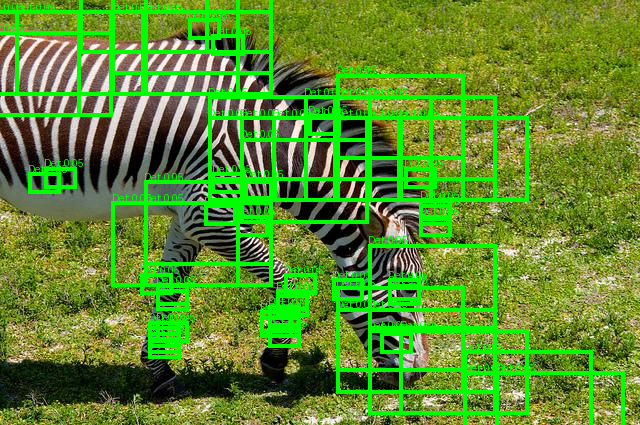

In [89]:
import torchvision.transforms as T

# 1. Setup paths and imports for the RT-DETR repo
repo_dir = '/kaggle/working/RT-DETR/rtdetr_pytorch'
os.chdir(repo_dir)
if repo_dir not in sys.path:
    sys.path.insert(0, repo_dir)

# Import the RT-DETR config loader
from src.core import YAMLConfig

print("Loading PyTorch Model from Checkpoint...")
# Use the exact config and checkpoint paths you used for the ONNX export
config_path = 'configs/rtdetr/rtdetr_r18vd_6x_coco.yml'
checkpoint_path = 'output/rtdetr_r18vd_6x_coco/checkpoint.pth'

# Load the model directly into memory
cfg = YAMLConfig(config_path, resume=checkpoint_path)
model = cfg.model.cuda()
model.eval()

print("Searching for the exact image path in Kaggle Inputs...")
# 2. Automatically find the image
found_images = glob.glob('/kaggle/input/datasets/organizations/ultralytics/coco128/coco128/images/train2017/000000000034.jpg', recursive=True)

if not found_images:
    print("Image not found. Using fallback test image...")
    import urllib.request
    img_path = 'test_image.jpg'
    urllib.request.urlretrieve('https://ultralytics.com/images/zidane.jpg', img_path)
else:
    img_path = found_images[0]
    print(f"Found exact path: {img_path}")

# 3. Prepare the image (The Proper PyTorch Way)
img_raw = Image.open(img_path).convert('RGB')
w, h = img_raw.size

# RT-DETR requires ImageNet normalization
transform = T.Compose([
    T.Resize((640, 640)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Apply transforms and move to GPU
img_tensor = transform(img_raw).unsqueeze(0).cuda()

print("Running PyTorch Inference...")

# 4. Run Inference 
with torch.no_grad():
    output = model(img_tensor)

# 5. Process results 
logits = output.get('pred_logits')
boxes = output.get('pred_boxes')

if logits is None or boxes is None:
    print(f"Error: Unexpected keys. Available keys: {list(output.keys())}")
else:
    probs = logits.sigmoid()
    scores, labels = probs.max(-1)

    draw = ImageDraw.Draw(img_raw)
    count = 0
    
    for i, score in enumerate(scores[0]):
        if score > 0.048: 
            cx, cy, bw, bh = boxes[0][i].cpu().numpy()
            
            x1 = (cx - bw/2) * w
            y1 = (cy - bh/2) * h
            x2 = (cx + bw/2) * w
            y2 = (cy + bh/2) * h
            
            draw.rectangle([x1, y1, x2, y2], outline="#00FF00", width=4)
            draw.text((x1, y1 - 10), f"Det: {score:.2f}", fill="#00FF00")
            count += 1

    print(f"Detection complete! Found {count} objects.")
    
    # 6. Save and Display
    output_path = '/kaggle/working/custom_result.jpg'
    img_raw.save(output_path)
    print(f"Image saved as {output_path} in your main working folder!")
    
    display(img_raw)